In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/GPT-from-Scratch/notebooks/"
os.chdir(PROJECT_DIR)
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/GPT-from-Scratch/notebooks


In [8]:
import torch
import os
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tokenizers import Tokenizer

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [10]:
tokenizer = Tokenizer.from_file("../src/tokenizer/arabic_bpe_tokenizer.json")

with open("../data/pretrain/data.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

token_ids = tokenizer.encode(raw_text).ids
print("Total token count:", len(token_ids))

Total token count: 320053


In [12]:
class GPTDataset(Dataset):
    def __init__(self, token_ids, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1:i + max_length + 1]

            self.input_ids.append(torch.tensor(input_chunk, dtype=torch.long))
            self.target_ids.append(torch.tensor(target_chunk, dtype=torch.long))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [13]:
context_length = 128
stride = 64
batch_size = 8

dataset = GPTDataset(token_ids, max_length=context_length, stride=stride)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print("Samples:", len(dataset))
print("Batches:", len(dataloader))

Samples: 4999
Batches: 624


In [14]:
split_idx = int(0.9 * len(dataset))
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [split_idx, len(dataset) - split_idx],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 562
Val batches: 63


In [15]:
import torch
import torch.nn as nn

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [16]:
class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi, device=x.device)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [17]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [18]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2).contiguous()
        context_vec = context_vec.view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec

In [19]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_resid = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_resid(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_resid(x)
        x = x + shortcut

        return x

In [20]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [21]:
GPT_CONFIG = {
    "vocab_size": 5000,
    "context_length": 128,
    "emb_dim": 256,
    "n_heads": 4,
    "n_layers": 4,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [22]:
model = GPTModel(GPT_CONFIG).to(device)

In [23]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)
    loss = F.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )
    return loss

In [24]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0

    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    model.eval()
    with torch.no_grad():
        for i, (input_batch, target_batch) in enumerate(data_loader):
            if i >= num_batches:
                break
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()

    return total_loss / num_batches

In [25]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [26]:
def decode_ids(ids, tokenizer):
    return tokenizer.decode(ids.squeeze(0).tolist())

In [34]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)

num_epochs = 6
eval_freq = 100
train_losses = []
val_losses = []
steps = []

In [35]:
global_step = 0

for epoch in range(num_epochs):
    model.train()

    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()

        loss = calc_loss_batch(input_batch, target_batch, model, device)
        loss.backward()
        optimizer.step()

        if global_step % eval_freq == 0:
            train_loss = calc_loss_loader(train_loader, model, device, num_batches=20)
            val_loss = calc_loss_loader(val_loader, model, device, num_batches=20)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            steps.append(global_step)

            print(f"Epoch {epoch+1}, Step {global_step}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

        global_step += 1

Epoch 1, Step 0: train_loss=3.7076, val_loss=4.4307
Epoch 1, Step 100: train_loss=3.6282, val_loss=4.4384
Epoch 1, Step 200: train_loss=3.4854, val_loss=4.4068
Epoch 1, Step 300: train_loss=3.4571, val_loss=4.3785
Epoch 1, Step 400: train_loss=3.4110, val_loss=4.3475
Epoch 1, Step 500: train_loss=3.3714, val_loss=4.3279
Epoch 2, Step 600: train_loss=3.3137, val_loss=4.3360
Epoch 2, Step 700: train_loss=3.2376, val_loss=4.2687
Epoch 2, Step 800: train_loss=3.0900, val_loss=4.2549
Epoch 2, Step 900: train_loss=3.0512, val_loss=4.2509
Epoch 2, Step 1000: train_loss=2.9644, val_loss=4.2257
Epoch 2, Step 1100: train_loss=2.8913, val_loss=4.1907
Epoch 3, Step 1200: train_loss=2.9387, val_loss=4.2144
Epoch 3, Step 1300: train_loss=2.7375, val_loss=4.1633
Epoch 3, Step 1400: train_loss=2.7180, val_loss=4.1579
Epoch 3, Step 1500: train_loss=2.6676, val_loss=4.1443
Epoch 3, Step 1600: train_loss=2.5237, val_loss=4.0822
Epoch 4, Step 1700: train_loss=2.5033, val_loss=4.1082
Epoch 4, Step 1800: tr

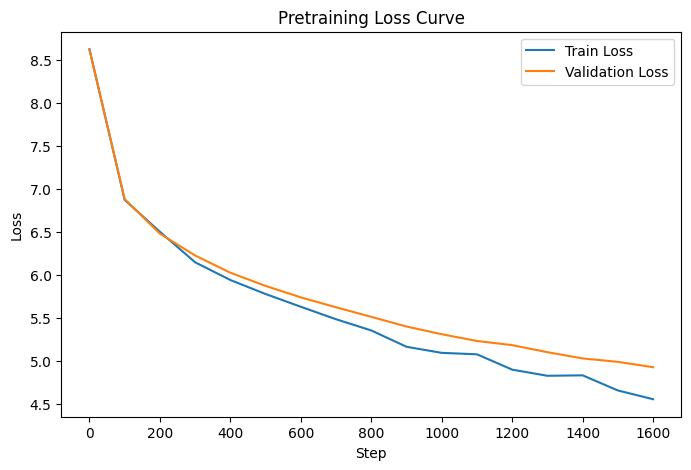

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(steps, train_losses, label="Train Loss")
plt.plot(steps, val_losses, label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Pretraining Loss Curve")
plt.legend()
plt.savefig("../results/plots/pretrain_loss.png")
plt.show()

In [36]:
prompt = "على"
prompt_ids = tokenizer.encode(prompt).ids
input_tensor = torch.tensor(prompt_ids, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
generated = generate_text_simple(
    model=model,
    idx=input_tensor,
    max_new_tokens=30,
    context_size=GPT_CONFIG["context_length"]
)

print("Generated IDs:")
print(generated)

print("\nGenerated text:")
print(decode_ids(generated.cpu(), tokenizer))

Generated IDs:
tensor([[ 181,  178,   83,  310,   84,  179, 4079,  170,   83,  223,  277,   84,
          169,   83, 2160, 2146,   84,    6,  254,  616,  564,  616, 2282,  377,
           83,  310,  266,   84,  289,  188,  686]], device='cuda:0')

Generated text:
على أن « سيتي » قد اغتصبه من « رعمسيس الثاني » في « أبو كبير » ( راجع الجزء الثالث الجزء الخامس )، « سيتي الأول » أنه كان يحمل


In [ ]:
torch.save(model.state_dict(), "../checkpoints/pretrained/pretrained_model.pth")
print("Pretrained model saved.")

Pretrained model saved.


In [ ]:
sample_text = decode_ids(generated.cpu(), tokenizer)

with open("../results/sample_generations/pretrain_sample.txt", "w", encoding="utf-8") as f:
    f.write(sample_text)

print(sample_text)

على جدران معبد « آمون » في « آمون » في « رعمسيس الثاني » في « رعمسيس الثاني » في « رعمسيس الثاني » في « العرابة المدفونة »، وقد


In [37]:
prompt = "وقد"
prompt_ids = tokenizer.encode(prompt).ids
input_tensor = torch.tensor(prompt_ids, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
generated = generate_text_simple(
    model=model,
    idx=input_tensor,
    max_new_tokens=30,
    context_size=GPT_CONFIG["context_length"]
)

print("Generated IDs:")
print(generated)

print("\nGenerated text:")
print(decode_ids(generated.cpu(), tokenizer))

Generated IDs:
tensor([[ 239,  939,  192,  169,  100, 1021,  688,   94,  344,  179,  329,  192,
         1891,  417,  182,  170,  229,  525, 3874,   93,  123, 4114,  221,  174,
          114,  175,   11,  213,  554,   83,  310]], device='cuda:0')

Generated text:
وقد أخذ وا في إ تما مه ؛ إذ قد مثل وا طف فر ًا من الق رى المجاورة ، ف أظهر كل ما س ها . وب ناء « سيتي
